# Phase 2 — Dataset Preparation for Machine Learning

**Project:** “Machine Learning approaches for accelerating antibiotic susceptibility testing (AST) in microfluidic systems” 

**Date:** May 2026 

## 1. Introduction

This notebook prepares the preprocessed dataset for machine learning by extracting meaningful features from the raw time-series data and assigning binary growth labels.

### Objectives
- Parse and restructure the dataset into a long-format DataFrame
- Engineer time-dependent features from the GVR time series
- Define and assign binary labels based on bacterial growth
- Save the final labelled dataset for use in the modelling phase

### Input
- `ecoli_ampli.pkl` — cleaned dataset from Phase 1

### Output
- `ecoli_ampli_ml.csv` — labelled feature matrix ready for modelling

### Features

| Feature | Description |
|---|---|
| `time` | Timepoint of the measurement (hours) |
| `initial_std` | Standard deviation across all tubes at t=0 |
| `current_std` | Standard deviation across all tubes at timepoint t |
| `tube_std` | Cumulative standard deviation of the tube up to t |
| `slope` | Rate of change from the initial GVR value |
| `delta` | Absolute change from the initial GVR value |
| `auc` | Area under the GVR curve up to timepoint t |
| `derivative` | Instantaneous rate of change from t-1 to t |

## Table of Contents
1. [Introduction](#1-introduction)
2. [Imports & Setup](#2-imports--setup)
3. [Data Loading](#3-dataset-loading)
4. [Feature Extraction](#4-feature-extraction)
5. [Feature Engineering](#5-feature-engineering)
6. [Data Quality Check](#6-data-quality)
7. [Label Preparation](#7-label-preparation)

## 2. Imports & Setup

In [1]:
# -- Data manipulation ------------------------------------------
import numpy as np
import pandas as pd
from IPython.display import display

# -- Visualisation ----------------------------------------------
import matplotlib.pyplot as plt

# -- Serialisation ----------------------------------------------
import pickle

## 3. Dataset loading

In [2]:
# Load the preprocessed dataset from Phase 1
with open("ecoli_ampli.pkl", "rb") as f:
    ecoli_ampli = pickle.load(f)

print("Dataset loaded successfully.")

Dataset loaded successfully.


## 4. Feature Extraction

### 4.1 Parse dataset structure

In [3]:
# Extract experiments, tube IDs, time series and GVR values
data_exp = []
dados = {}
tubo = []
tempo = {}
antibiotico = "Ampicillin"

for data, concs in ecoli_ampli.items():
    for conc, datasets in concs.items():
        df = datasets["gvr"]
        chave = data + "_" + conc
        data_exp.append(chave)

        colunas = df.columns[1:]
        dados[chave] = {}
        tempo[chave] = {}

        for col in colunas:
            t = col[:-2]
            if t not in tubo:
                tubo.append(t)
            else:
                None
            dados[chave][t] = df[col].values
            tempo[chave][t] = df["Time(hrs)"].values


### 4.2 Build long-format DataFrame

In [4]:
# Construct a record per (experiment, tube, timepoint)
registos = []

for experiencia in data_exp:
    for concentração in tubo:
        df_temp = pd.DataFrame({
            "experiencia": experiencia,
            "tubo_id": (experiencia + "_" + concentração),
            "tempo": tempo[experiencia][concentração],
            "antibiotico": antibiotico,
            "concentração": concentração,
            "gvr": dados[experiencia][concentração]
        })
        registos.append(df_temp)

for_ml = pd.concat(registos, ignore_index=True)
#display(for_ml)

## 5. Feature Engineering

### 5.1 Compute initial standard deviation per experiment

In [5]:
# Compute the initial cross-tube std for each experiment (t=0)
stds = {}

for exp, grupo in for_ml.groupby("experiencia"):

    data, conc = exp.split("_")

    df = ecoli_ampli[data][conc]["gvr"]

    std_inicial = np.std(df.iloc[0, 1:])

    stds[exp] = std_inicial

for_ml["std_inicial"] = (
    for_ml["experiencia"].map(stds))

### 5.2 Feature helper functions

In [6]:

def get_slope(gvr_inicial, gvr_atual, tempo):
    """Rate of change from the initial GVR value."""
    if tempo == 0:
        return 0
    resultado = (gvr_atual - gvr_inicial)/tempo
    return resultado

def get_delta(gvr_inicial, gvr_atual):
    """Absolute change from the initial GVR value."""
    return gvr_atual - gvr_inicial 

def get_auc(gvr_ateagora, tempo_ateagora):
    """Area under the GVR curve up to the current timepoint."""
    auc_parcial = np.trapz(gvr_ateagora, tempo_ateagora)
    return auc_parcial

def get_derivada(gvr_serie, tempo_serie, t):
    """Instantaneous derivative at timepoint t."""
    if t == 0:
        return 0
    return (gvr_serie[t] - gvr_serie[t-1]) / (tempo_serie[t] - tempo_serie[t-1])

### 5.3 Compute features for every timepoint

In [7]:
slope_lista = []
delta_lista = []
auc_lista = []
std_lista = []
derivada_lista= []
std_tubo = []

for experiencia in data_exp:
    data, conc = experiencia.split("_")
    df = ecoli_ampli[data][conc]["gvr"]
    
    for concentração in tubo:
        gvr_serie = dados[experiencia][concentração]
        tempo_serie = tempo[experiencia][concentração]
        gvr_inicial = gvr_serie[0]
        
        for t in range(len(tempo_serie)):
            std_t = np.std(df.iloc[t, 1:])
            std_lista.append(std_t)
            slope_lista.append(get_slope(gvr_inicial, gvr_serie[t], tempo_serie[t]))
            delta_lista.append(get_delta(gvr_inicial, gvr_serie[t]))
            std_tubo.append(np.std(gvr_serie[:t+1]))
            auc_lista.append(get_auc(gvr_serie[:t+1], tempo_serie[:t+1]))
            derivada_lista.append(get_derivada(gvr_serie, tempo_serie, t))

In [8]:
# Assign computed features to the ML DataFrame
for_ml["std_atual"] = std_lista
for_ml["std_tubo"] = std_tubo
for_ml["slope"] = slope_lista
for_ml["delta"] = delta_lista
for_ml["AUC"] = auc_lista
for_ml["Derivada"] = derivada_lista

In [9]:
display(for_ml)

,experiencia,tubo_id,tempo,antibiotico,concentração,gvr,std_inicial,std_atual,std_tubo,slope,delta,AUC,Derivada
0,20230508_5e6,20230508_5e6_Positive control,0.000000,Ampicillin,Positive control,0.069883,0.008784,0.008784,0.000000,0.000000,0.000000,0.000000,0.000000
1,20230508_5e6,20230508_5e6_Positive control,0.166667,Ampicillin,Positive control,0.069883,0.008784,0.008784,0.000000,0.000000,0.000000,0.011647,0.000000
2,20230508_5e6,20230508_5e6_Positive control,0.333333,Ampicillin,Positive control,-0.139765,0.008784,0.017568,0.098829,-0.628944,-0.209648,0.005824,-1.257887
3,20230508_5e6,20230508_5e6_Positive control,0.500000,Ampicillin,Positive control,-0.199132,0.008784,0.025127,0.121492,-0.538028,-0.269014,-0.022418,-0.356198
4,20230508_5e6,20230508_5e6_Positive control,0.666667,Ampicillin,Positive control,-0.119479,0.008784,0.024350,0.112185,-0.284042,-0.189362,-0.048969,0.477916
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8415,20230518_5e4,20230518_5e4_128,15.666667,Ampicillin,128,-0.203146,0.006013,1.223849,0.074035,-0.014303,-0.224081,-2.093829,0.163130
8416,20230518_5e4,20230518_5e4_128,15.833333,Ampicillin,128,-0.230334,0.006013,1.225105,0.074306,-0.015870,-0.251270,-2.129953,-0.163130
8417,20230518_5e4,20230518_5e4_128,16.000000,Ampicillin,128,-0.216759,0.006013,1.211603,0.074390,-0.014856,-0.237695,-2.167210,0.081449
8418,20230518_5e4,20230518_5e4_128,16.166667,Ampicillin,128,-0.197151,0.006013,1.210670,0.074272,-0.013490,-0.218087,-2.201703,0.117649


## 6. Data Quality

In [10]:
# Check for duplicate timepoints
n_duplicates = (for_ml.duplicated(subset=["experiencia", "concentração", "tempo"]).sum())
print(f"Duplicate rows : {n_duplicates}")

# Check for missing values
print("\nMissing values per column:")
print(for_ml.isnull().sum())

Duplicate rows : 0

Missing values per column:
experiencia     0
tubo_id         0
tempo           0
antibiotico     0
concentração    0
gvr             0
std_inicial     0
std_atual       0
std_tubo        0
slope           0
delta           0
AUC             0
Derivada        0
dtype: int64


## 7. Label Preparation

### 7.1 Feature Overview per Tube

To support label definition, we first inspect the final feature values for each tube.
The following charts display the cumulative features at the last recorded timepoint.

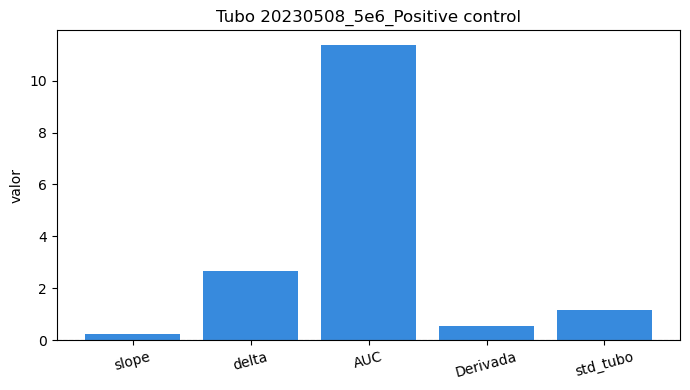

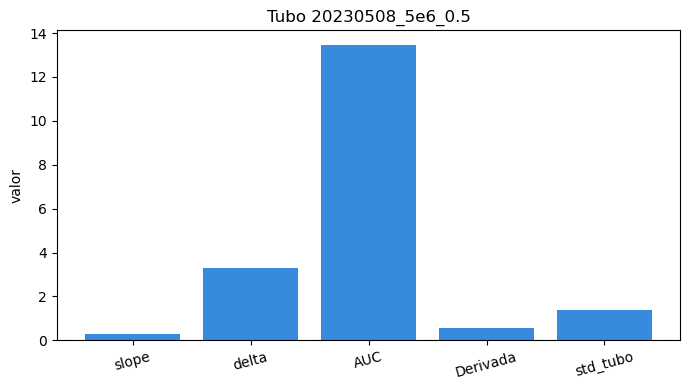

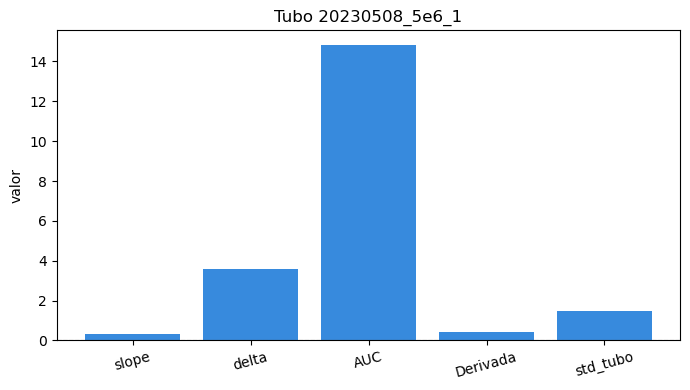

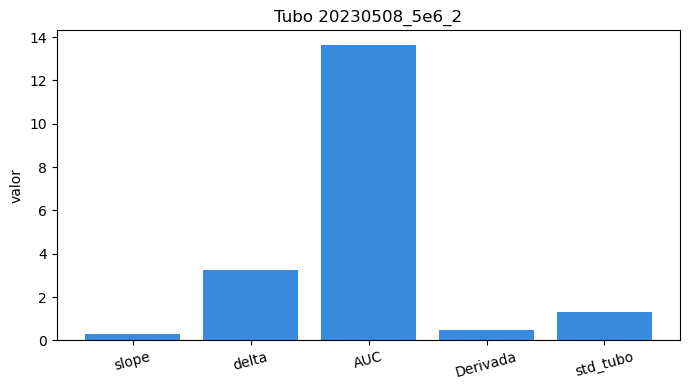

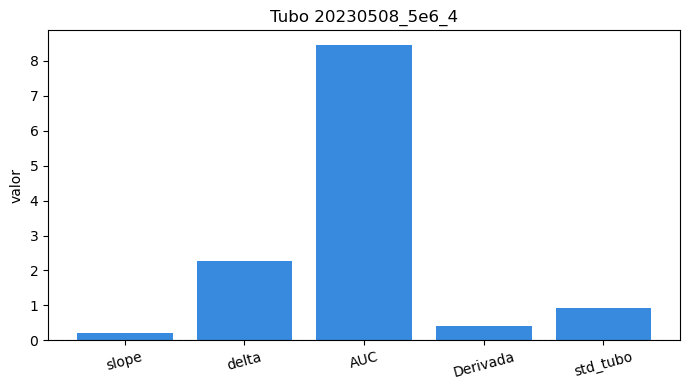

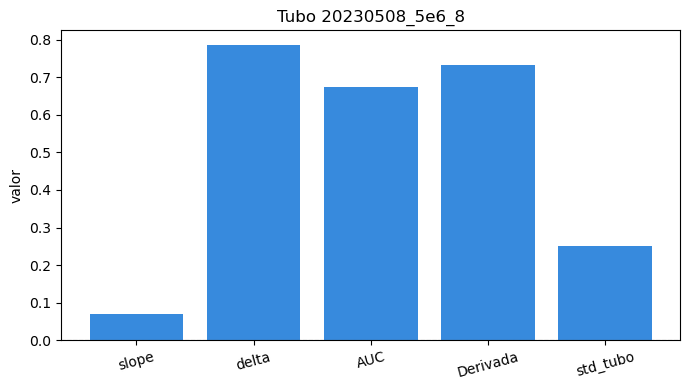

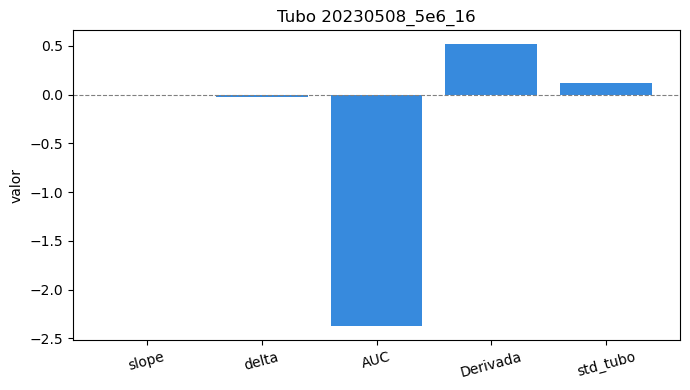

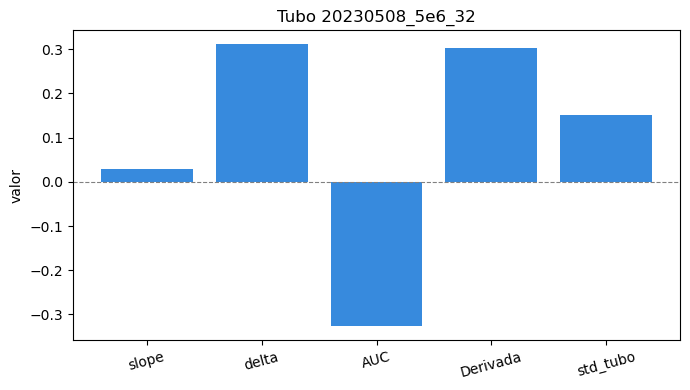

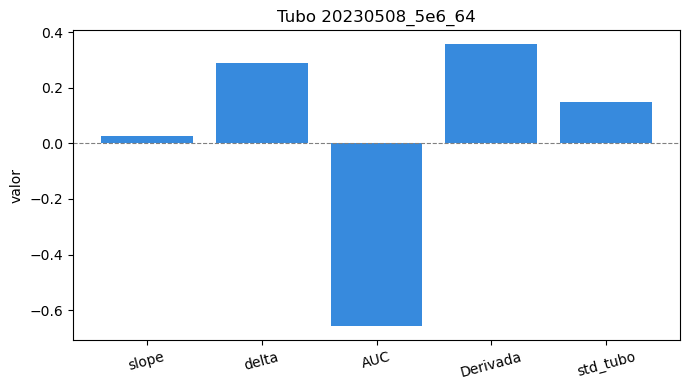

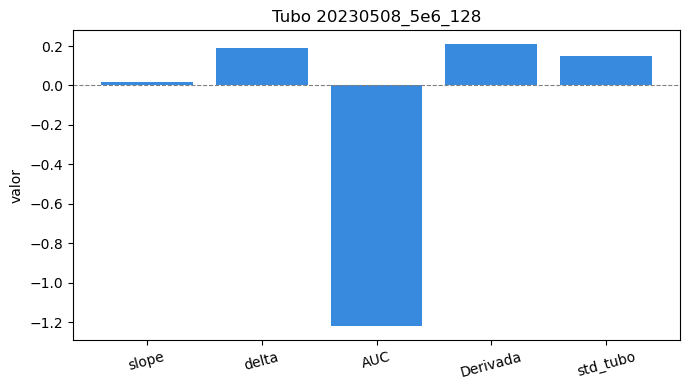

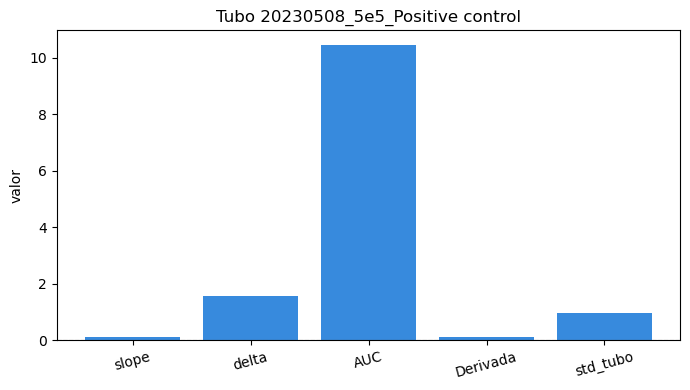

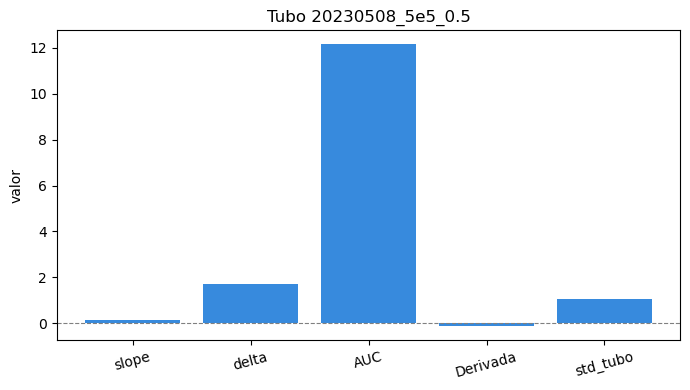

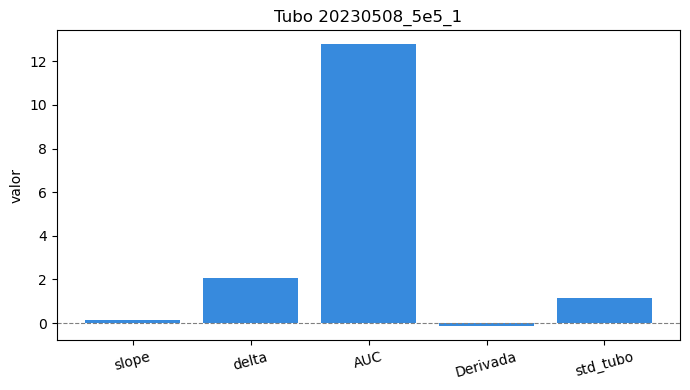

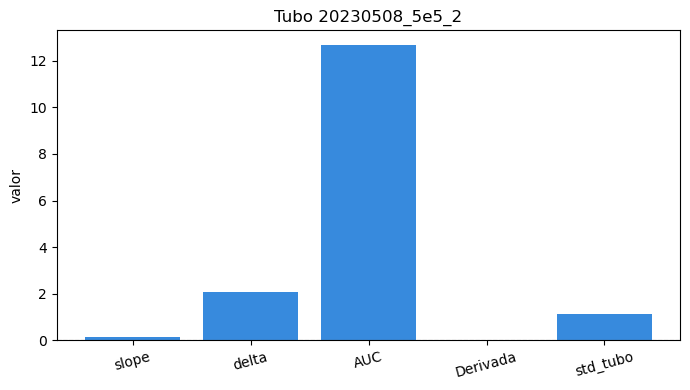

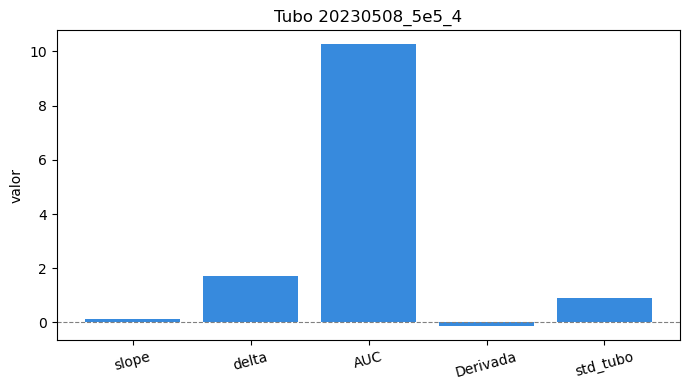

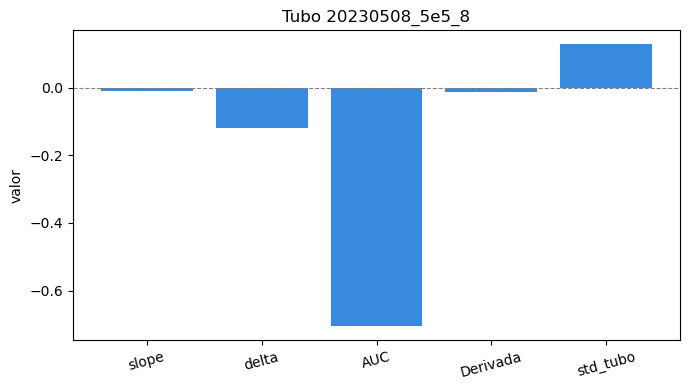

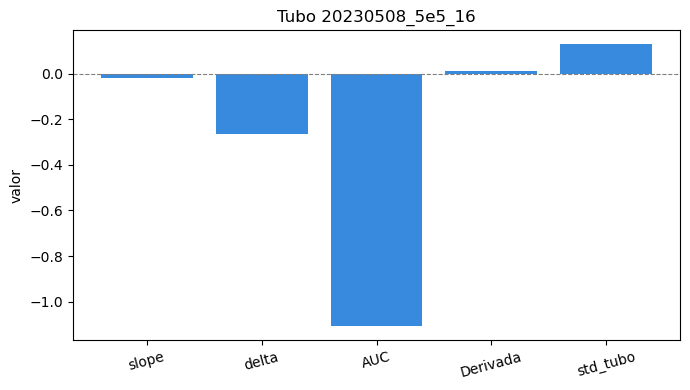

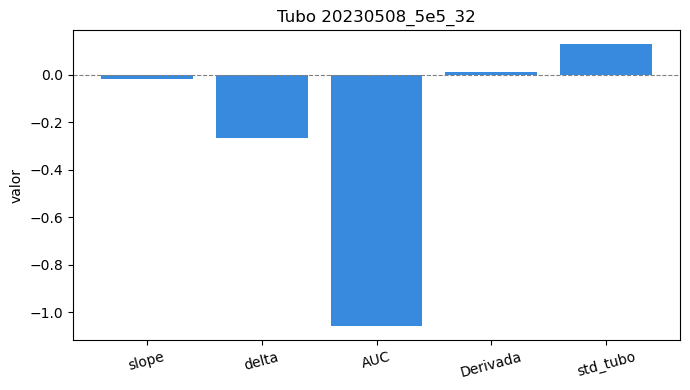

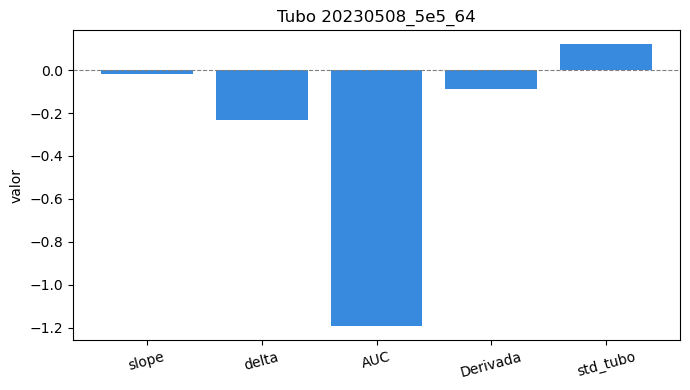

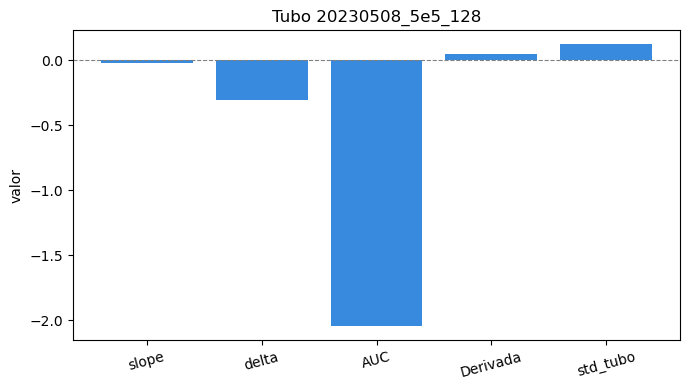

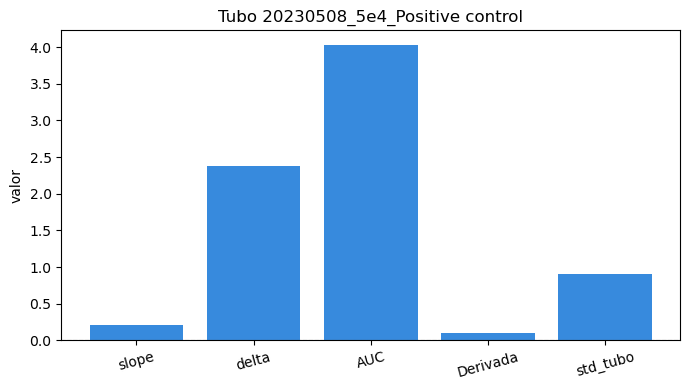

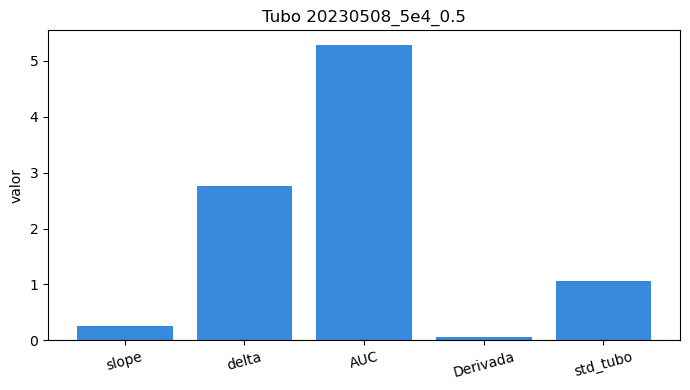

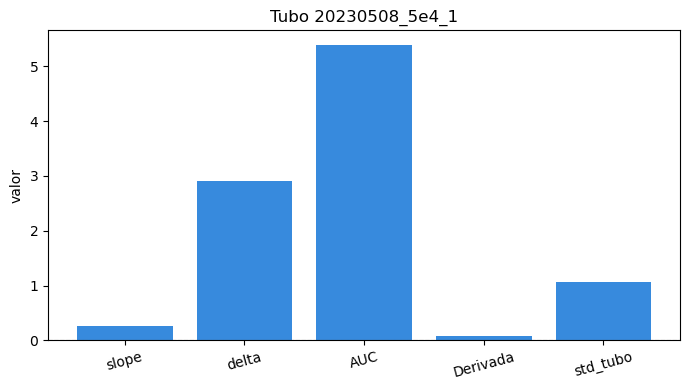

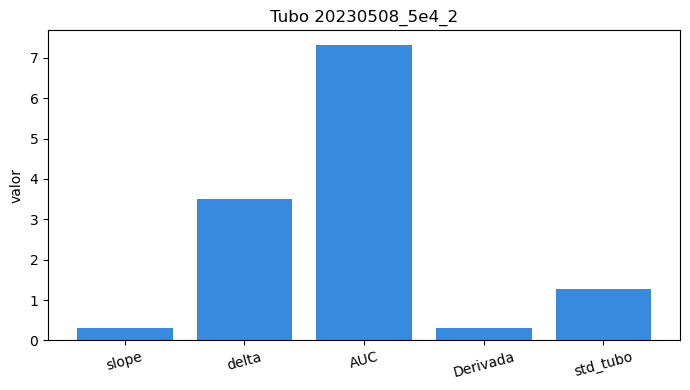

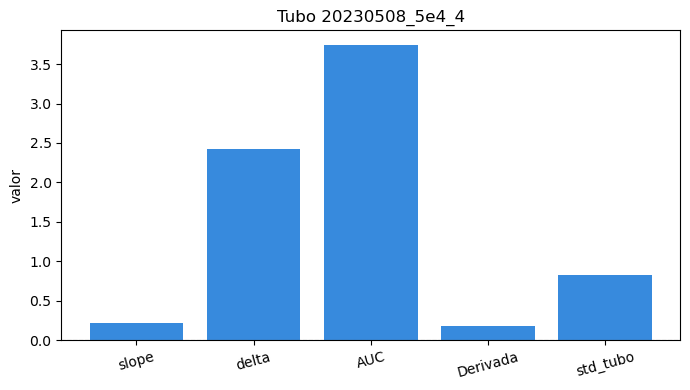

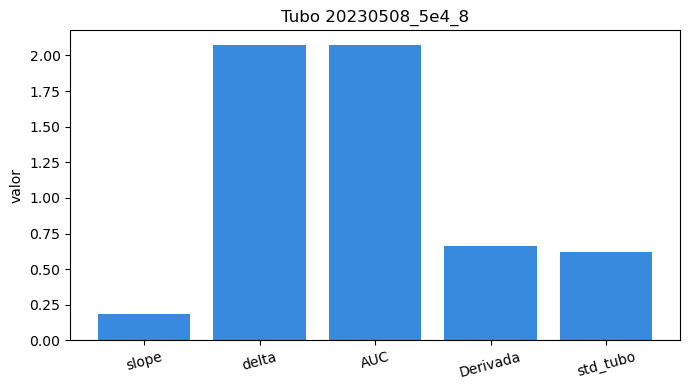

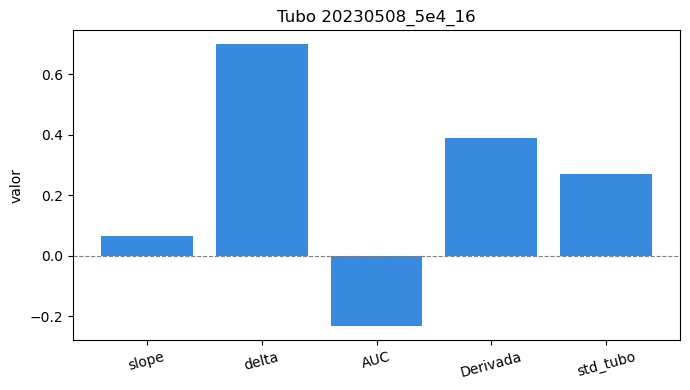

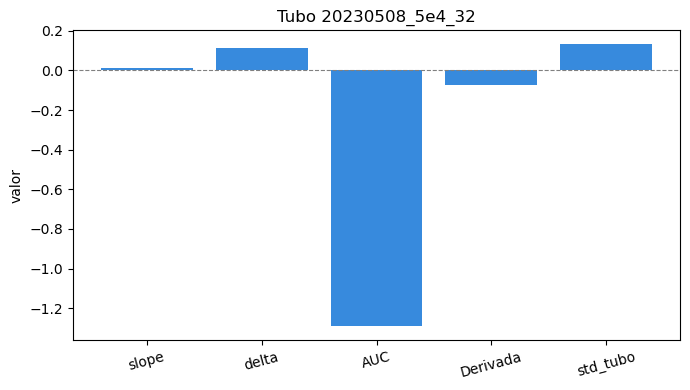

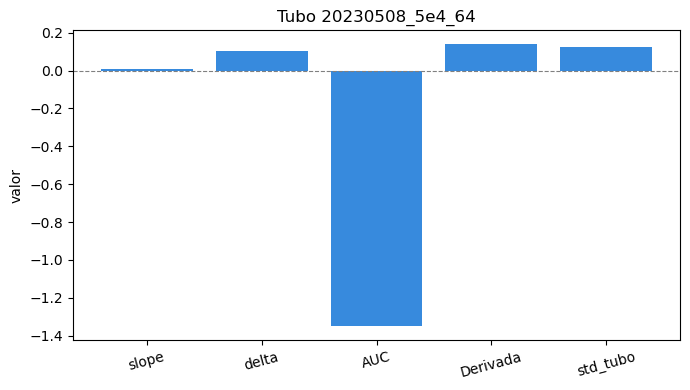

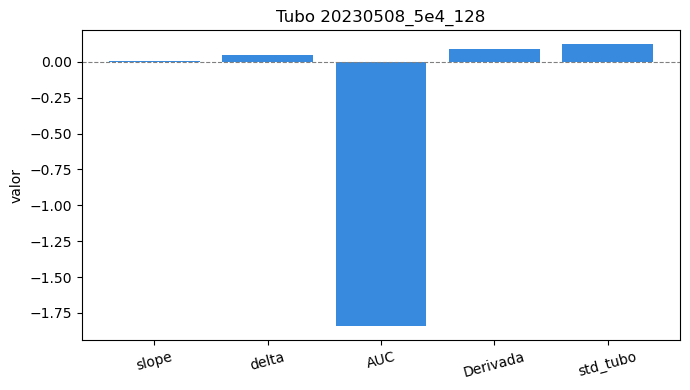

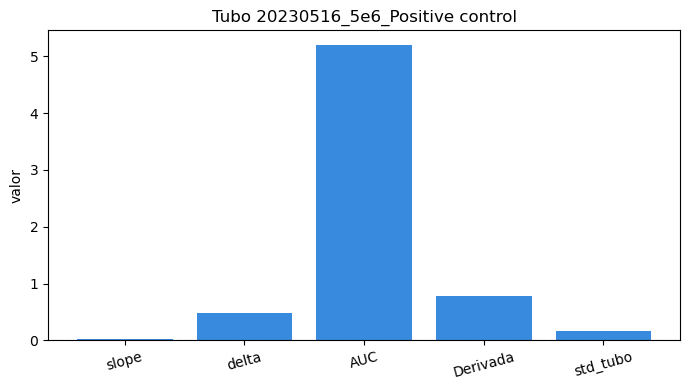

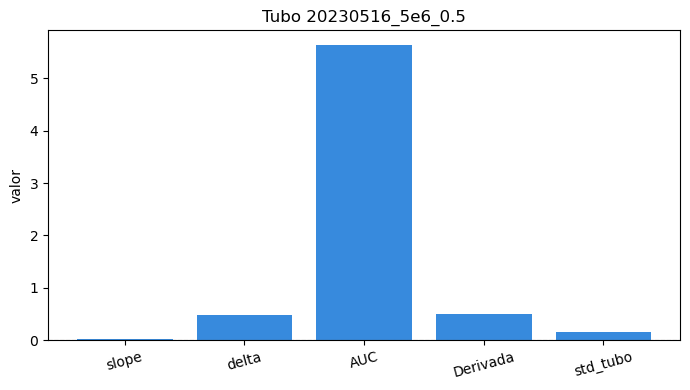

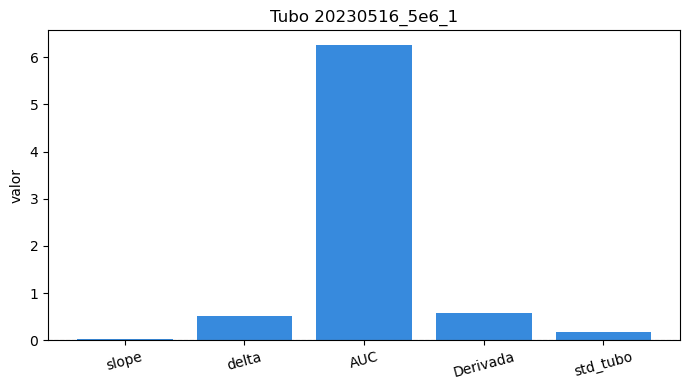

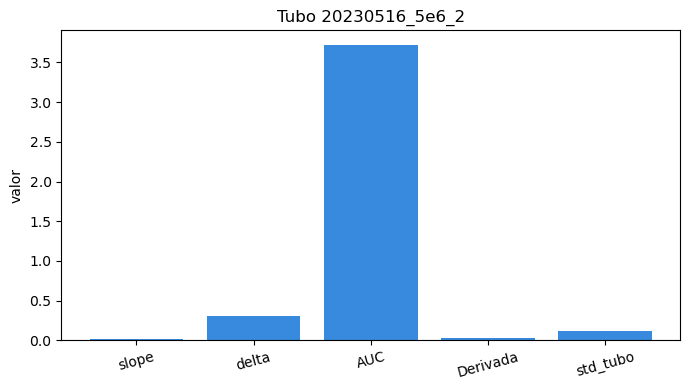

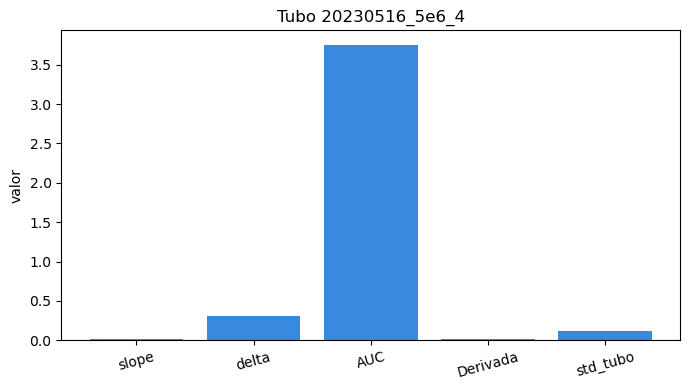

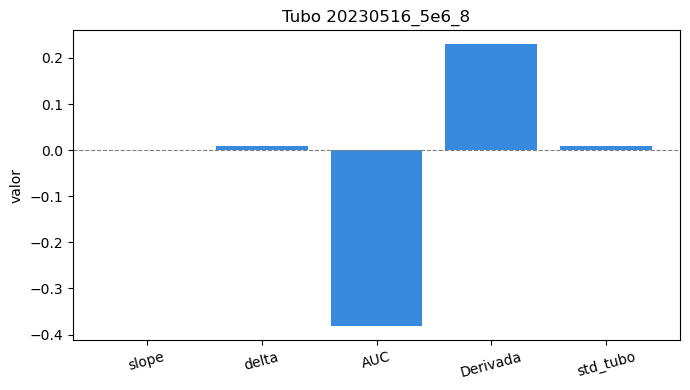

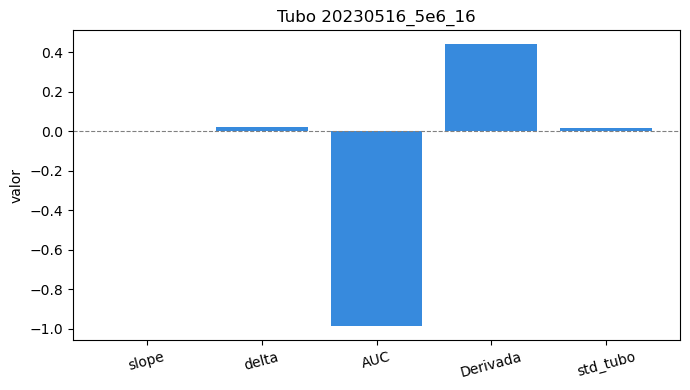

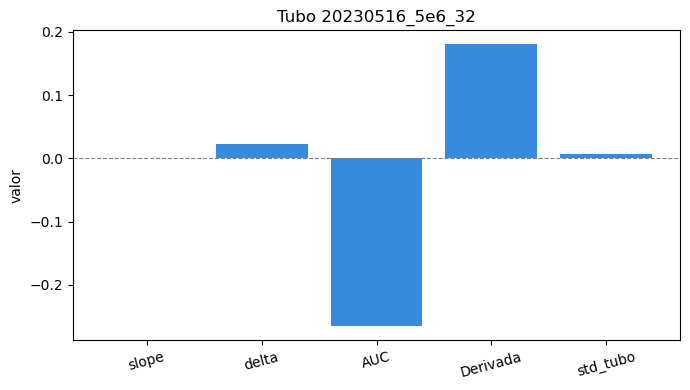

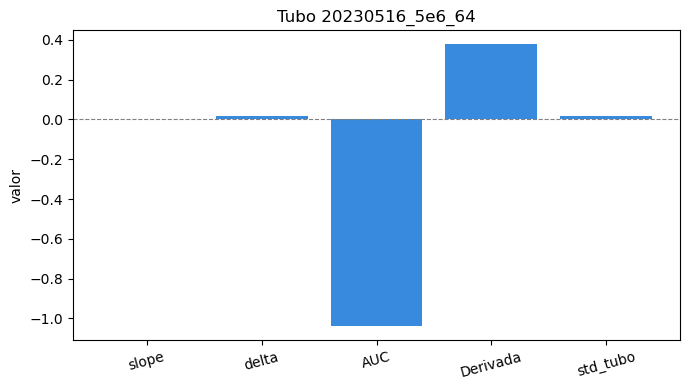

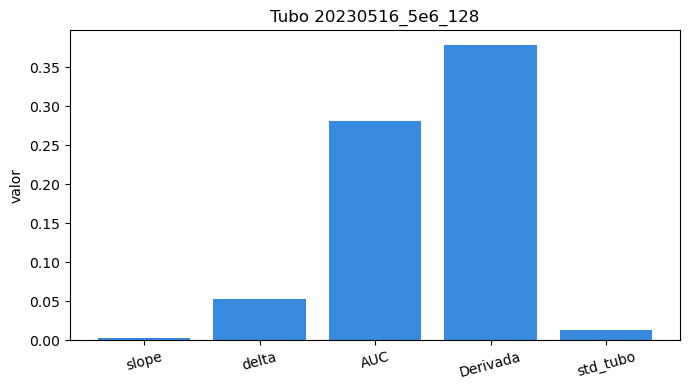

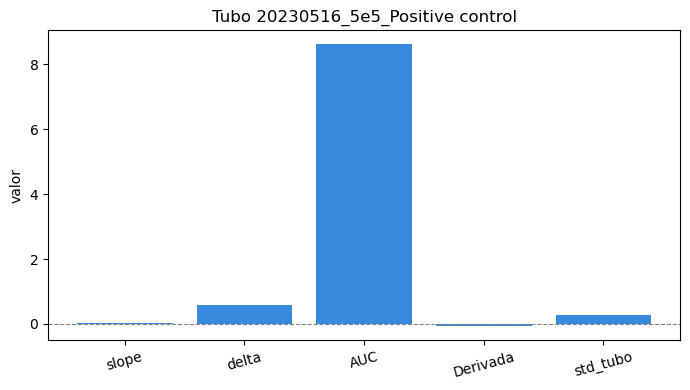

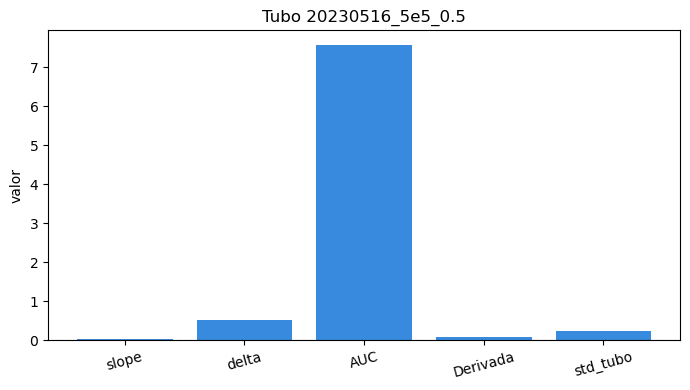

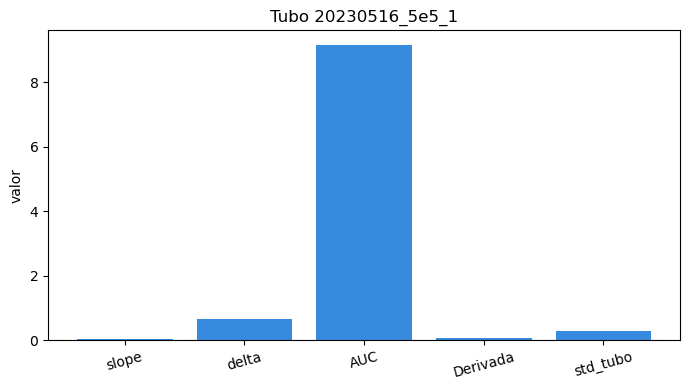

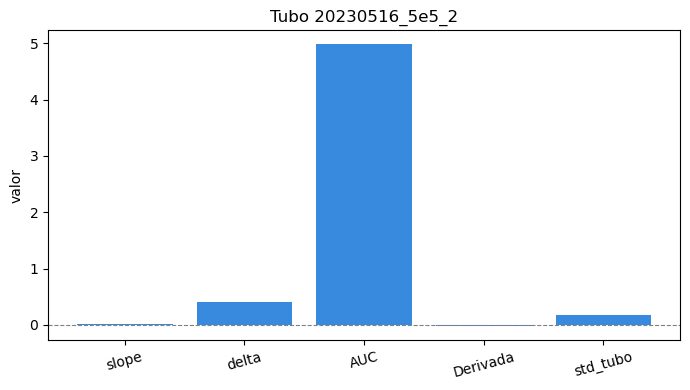

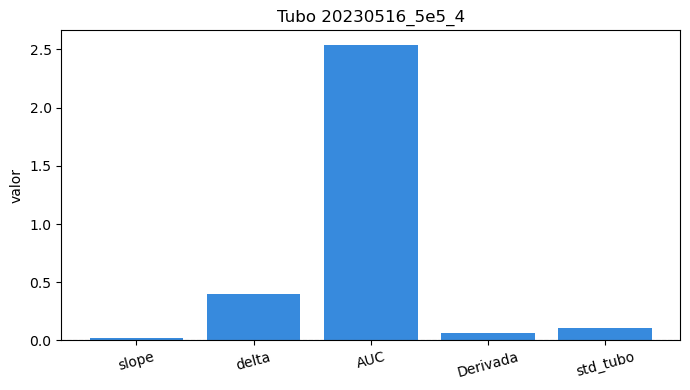

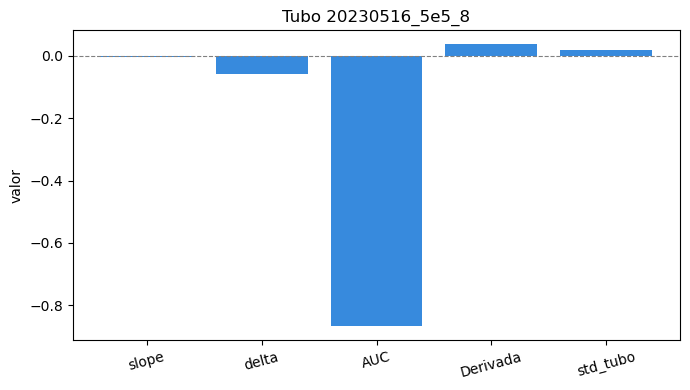

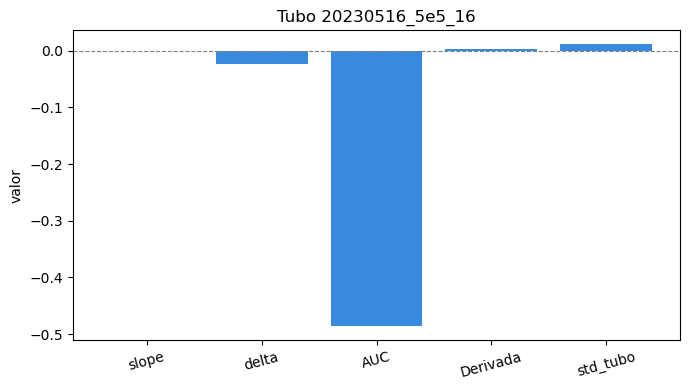

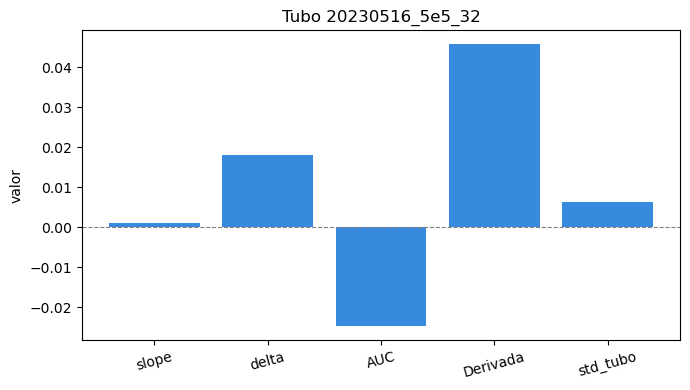

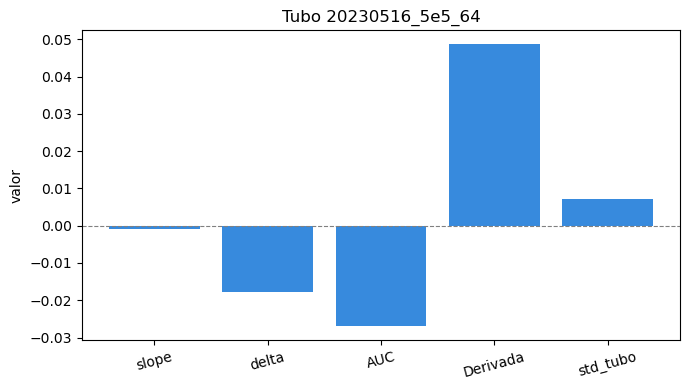

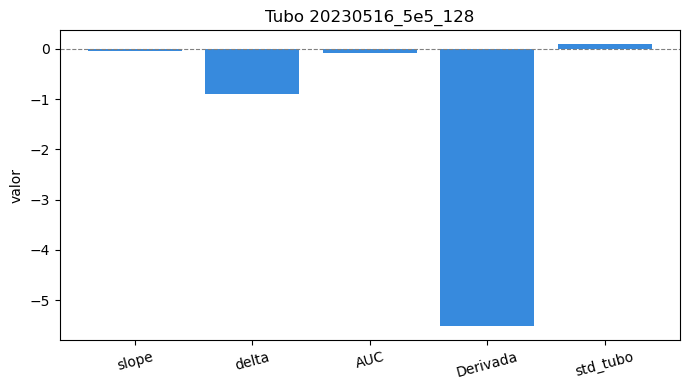

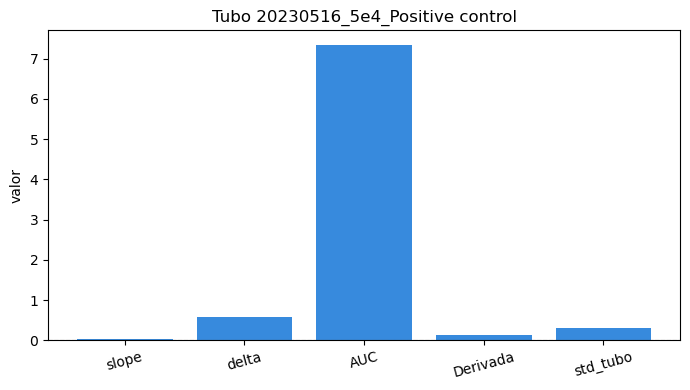

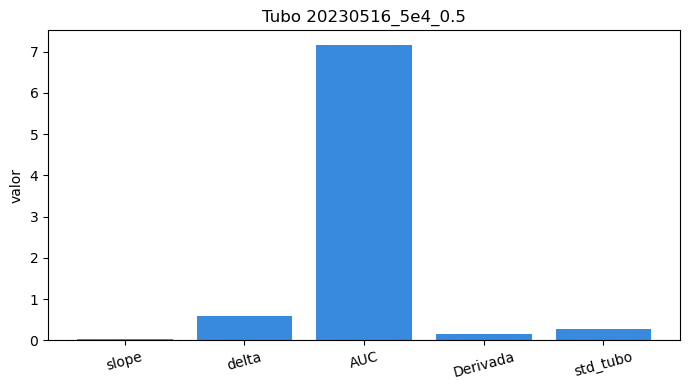

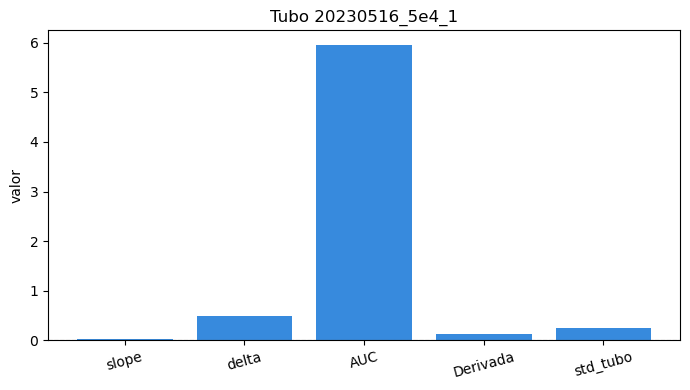

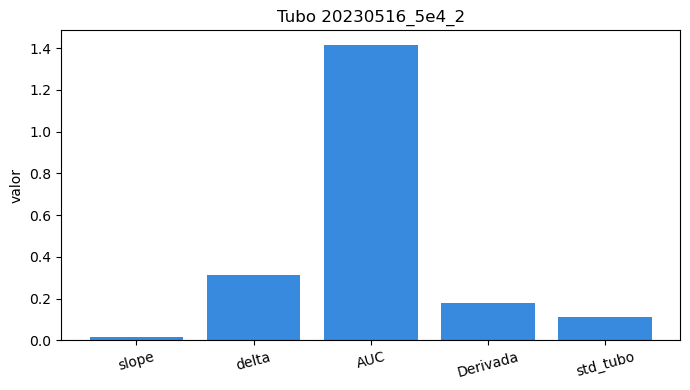

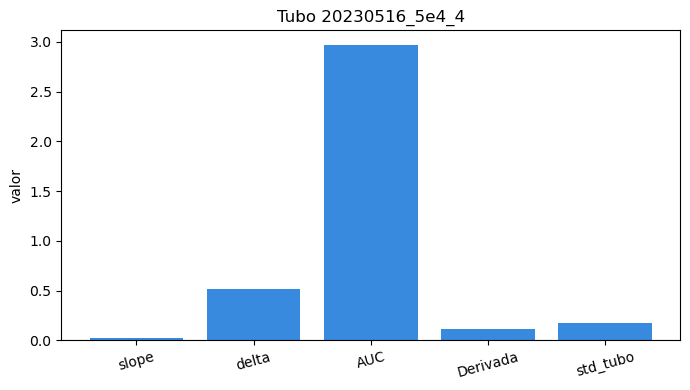

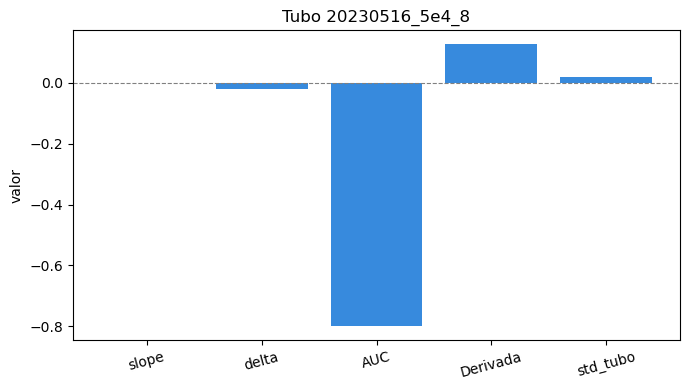

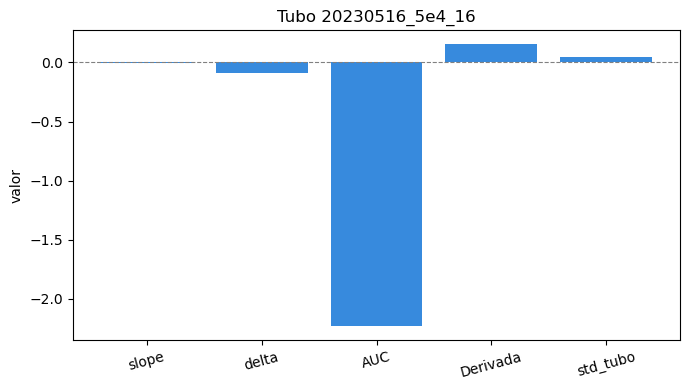

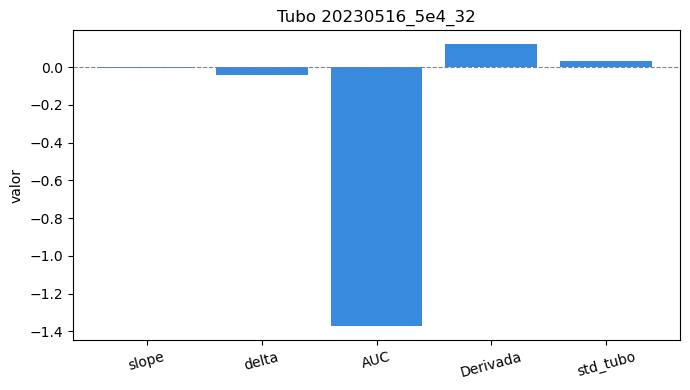

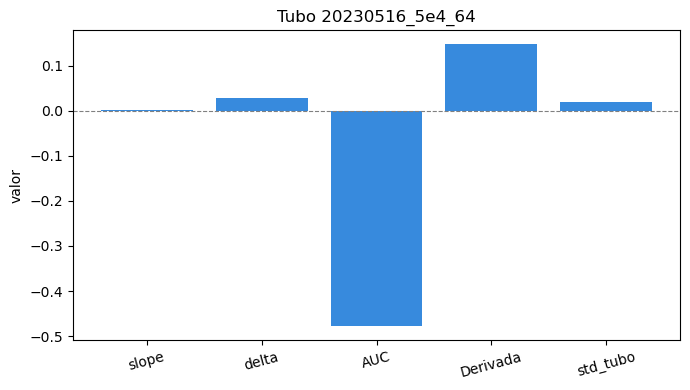

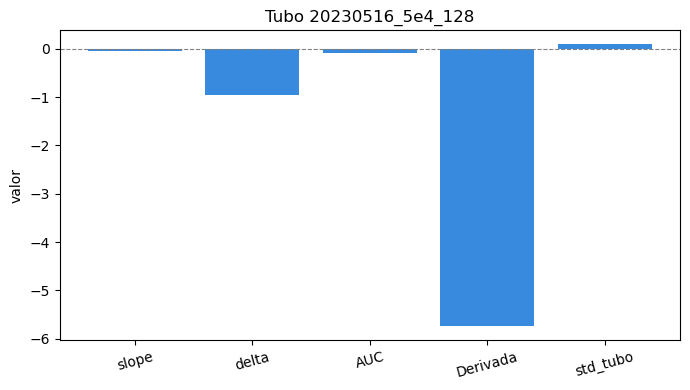

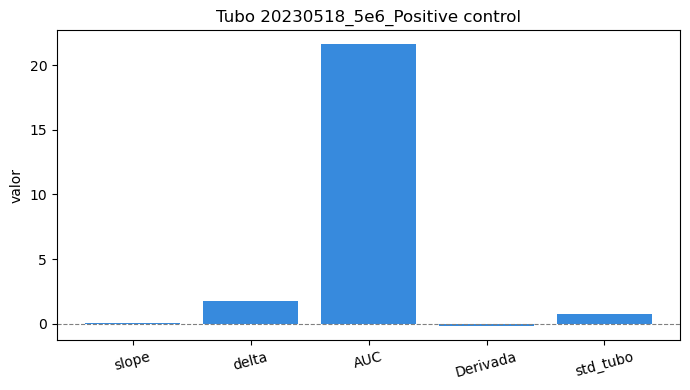

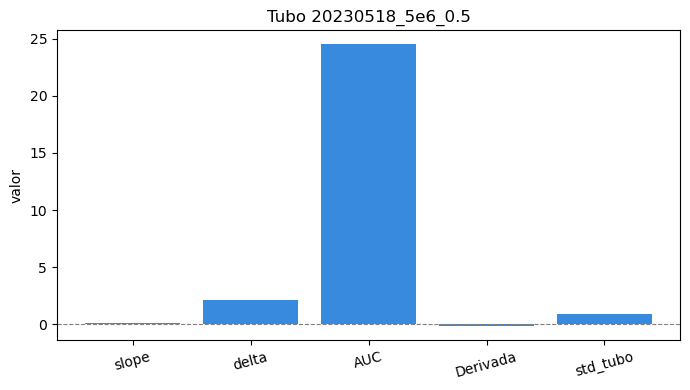

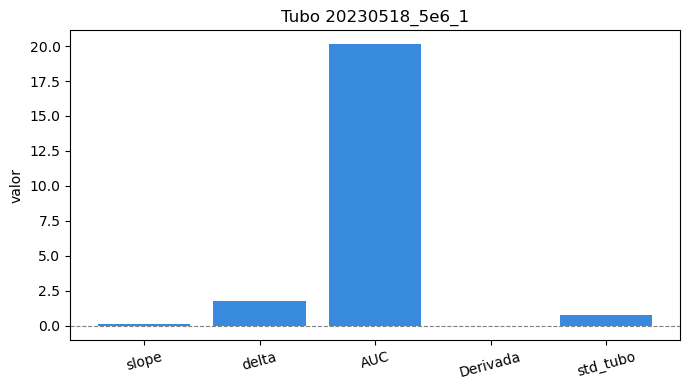

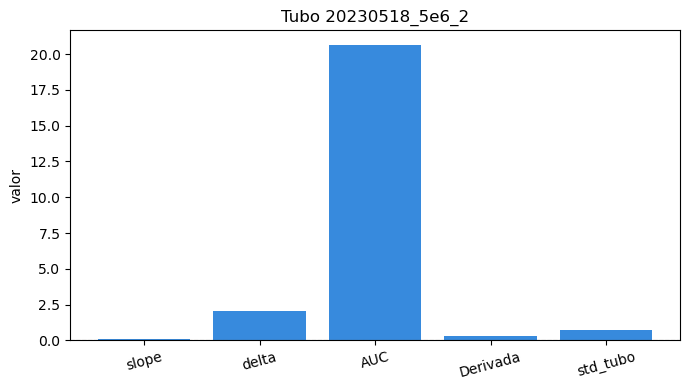

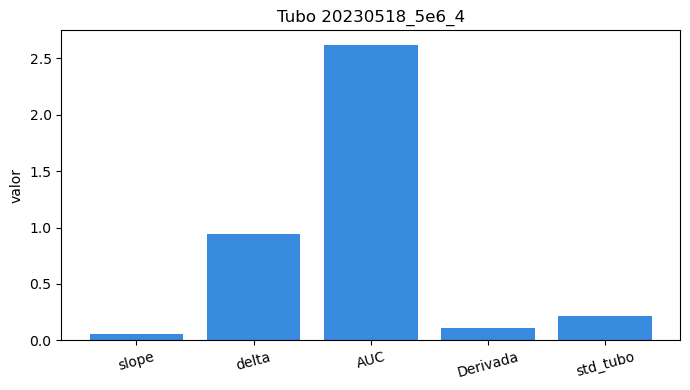

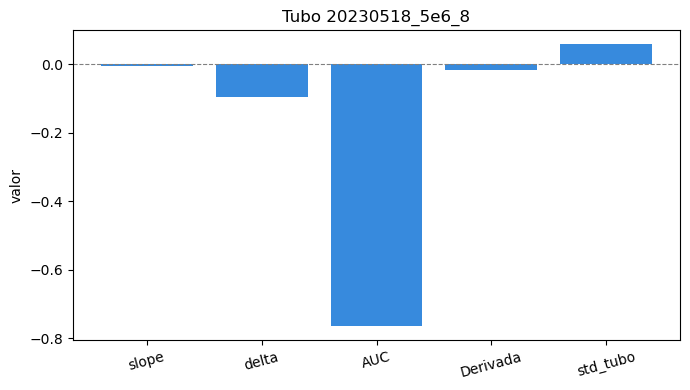

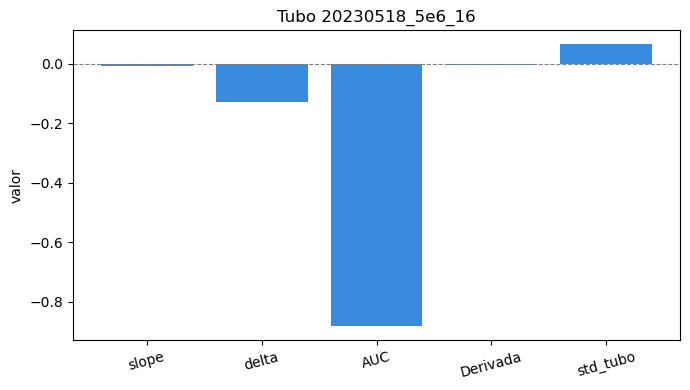

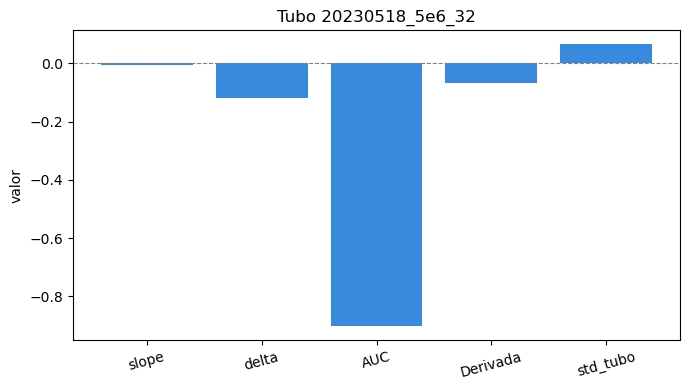

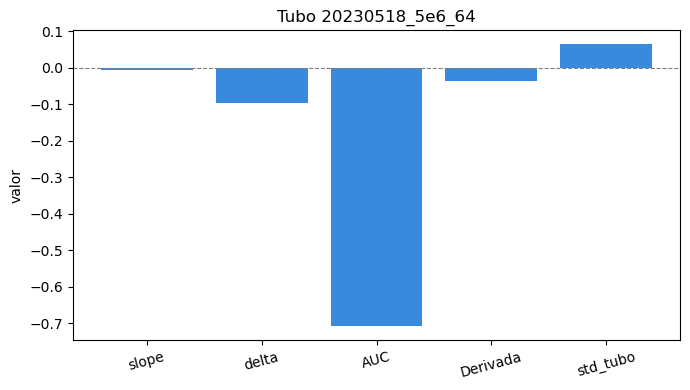

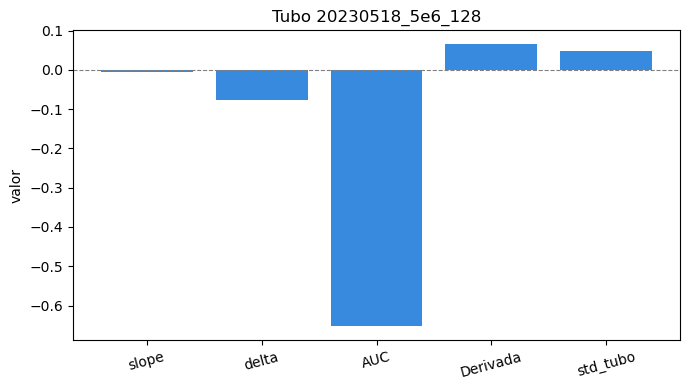

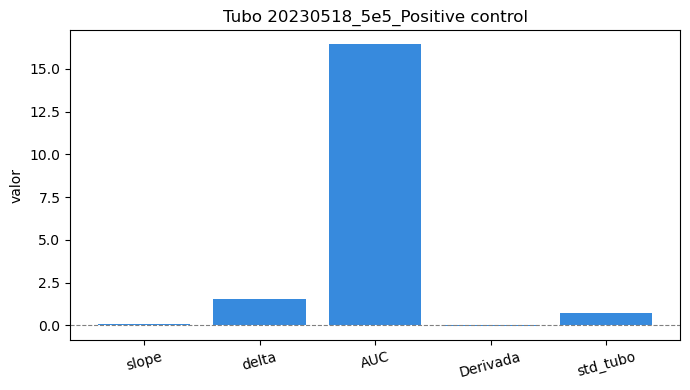

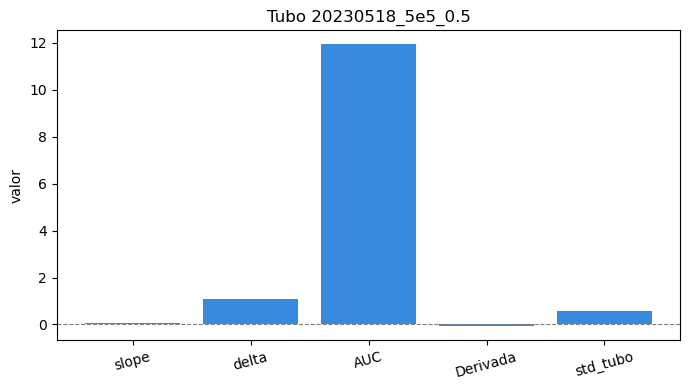

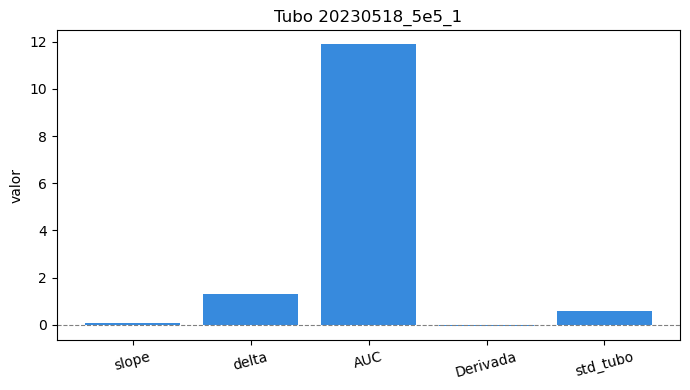

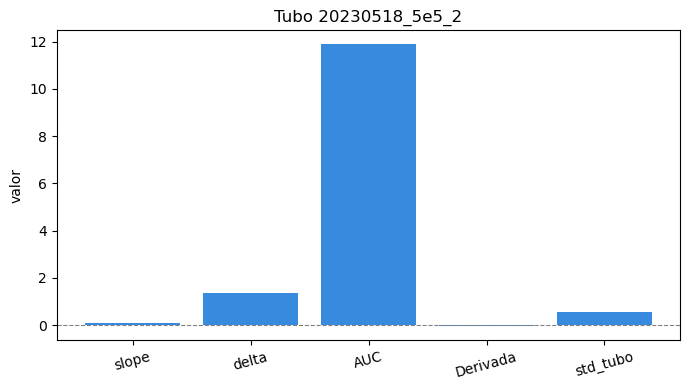

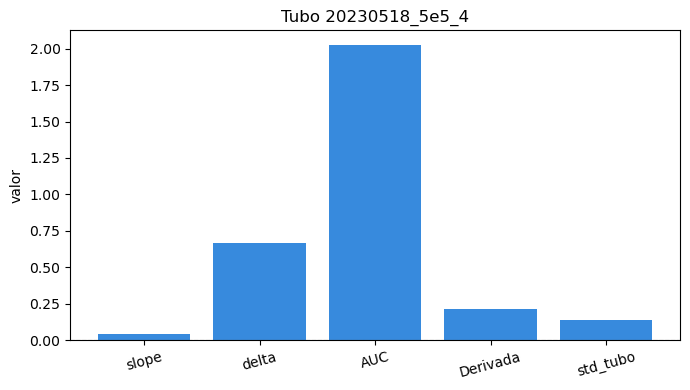

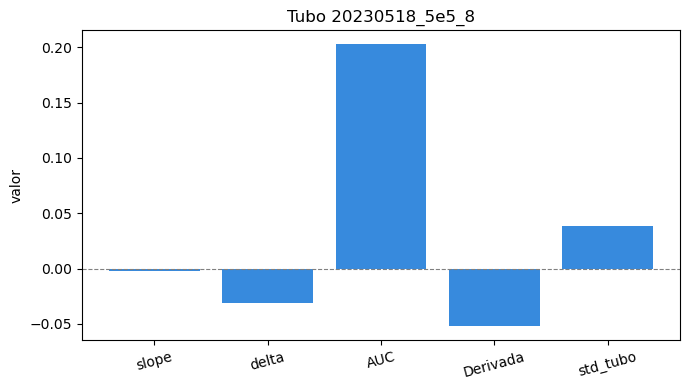

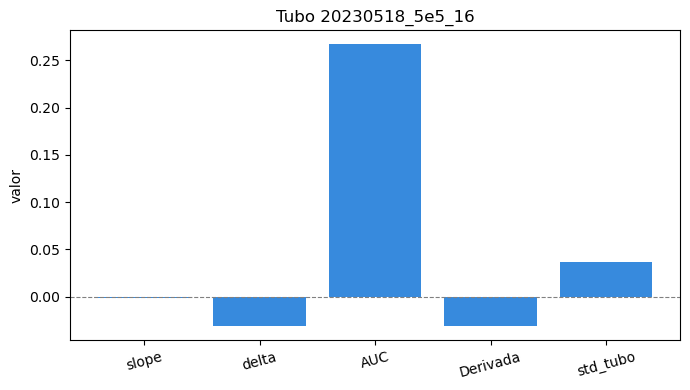

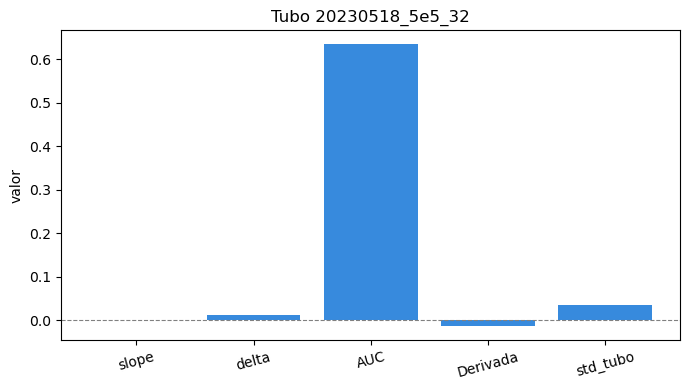

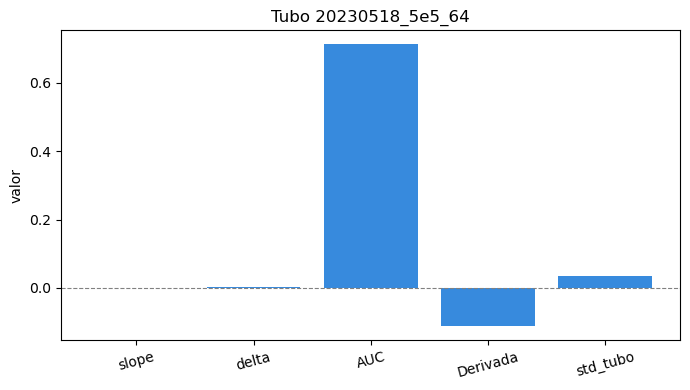

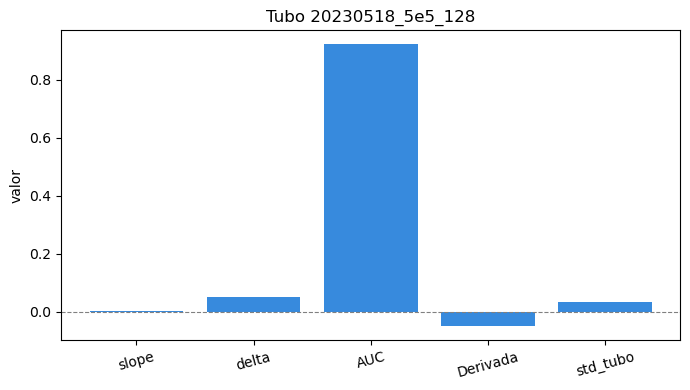

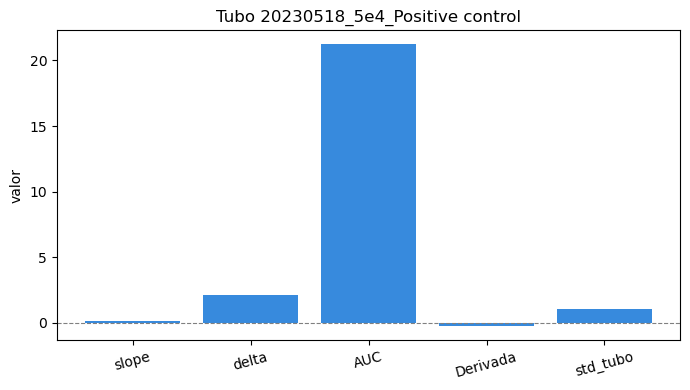

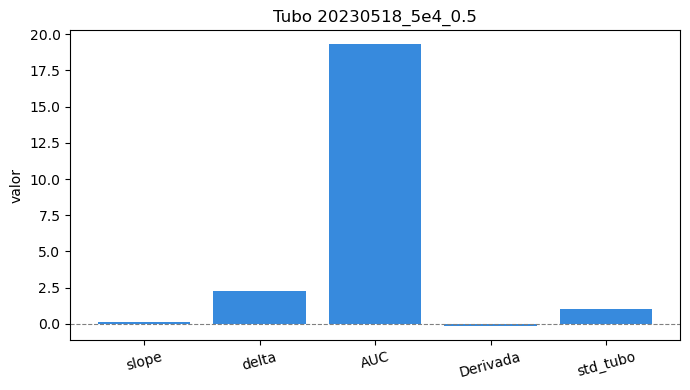

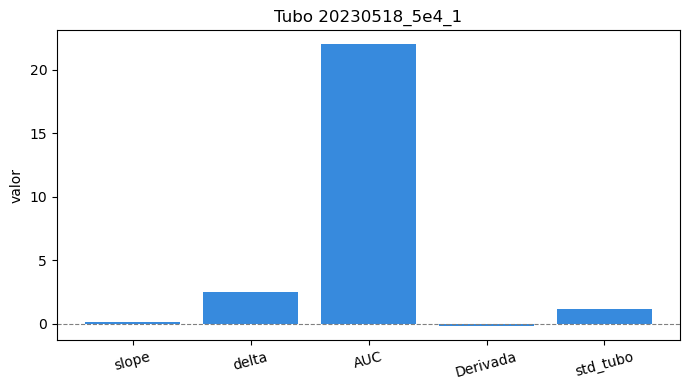

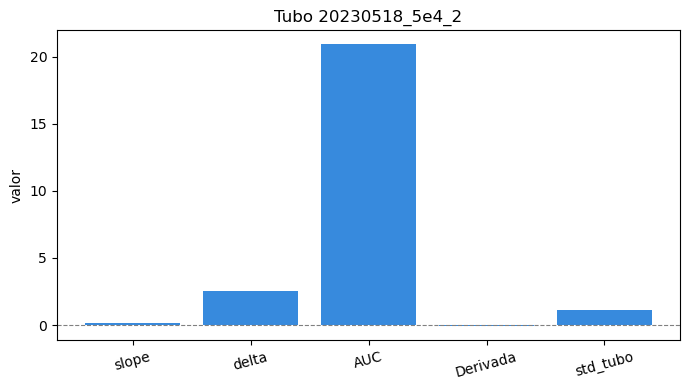

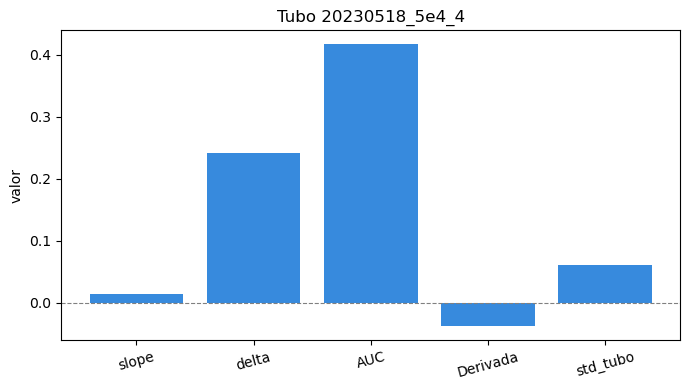

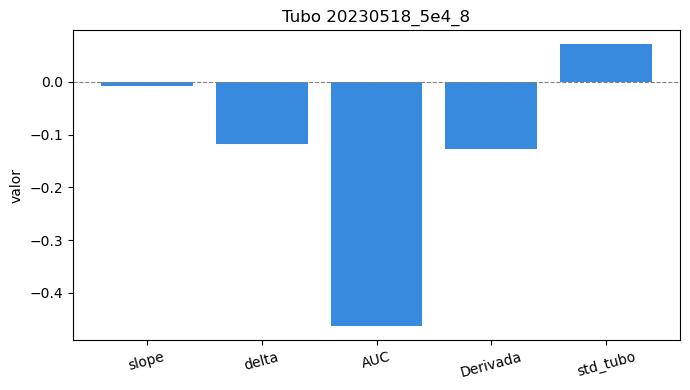

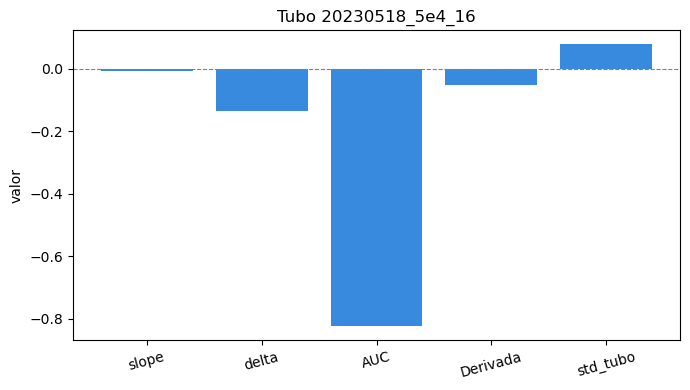

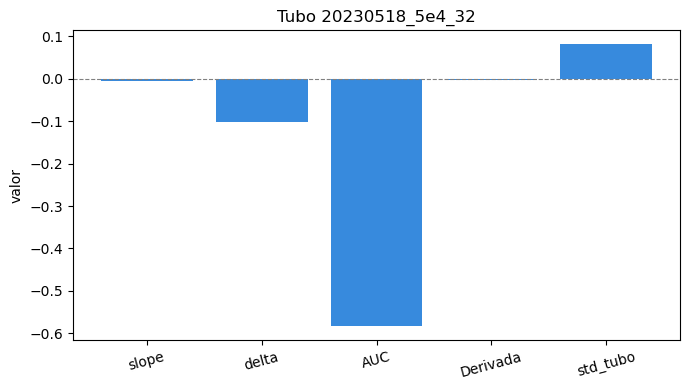

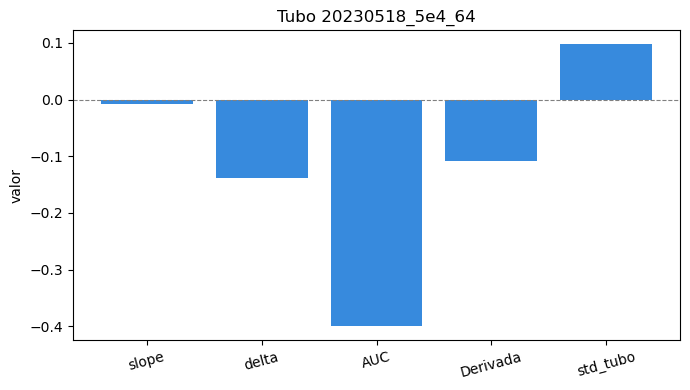

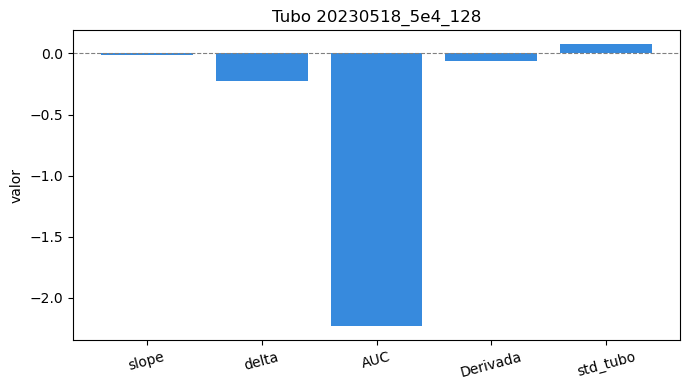

In [11]:

features = ["slope", "delta", "AUC", "Derivada", "std_tubo"]

# Extract the last timepoint for each tube
df_final = for_ml.drop_duplicates("tubo_id", keep="last")[["tubo_id"] + features].reset_index(drop=True)

# Plot feature values per tube
for _, row in df_final.iterrows():
    fig, ax = plt.subplots(figsize=(7, 4))
    
    ax.bar(features, row[features], color="#378ADD")
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_title(f"Tubo {row['tubo_id']}")
    ax.set_ylabel("valor")
    ax.tick_params(axis='x', rotation=15)
    
    plt.tight_layout()
    plt.show()

### 7.2 Label Definition

Labels are assigned based on bacterial growth, determined by the final AUC value:

| Label | Meaning | Condition |
|---|---|---|
| `0` | No growth | Final AUC ≤ 0 |
| `1` | Growth | Final AUC > 0 |

In [12]:
# Assign binary growth label based on final AUC per tube
for id_tubo in for_ml["tubo_id"].unique():
    subset = for_ml[for_ml["tubo_id"] == id_tubo]
    ultimo = subset.iloc[-1]
    
    label = "1" if ultimo["AUC"] > 0 else "0"
    
    for_ml.loc[for_ml["tubo_id"] == id_tubo, "label"] = label

In [13]:
display(for_ml)

,experiencia,tubo_id,tempo,antibiotico,concentração,gvr,std_inicial,std_atual,std_tubo,slope,delta,AUC,Derivada,label
0,20230508_5e6,20230508_5e6_Positive control,0.000000,Ampicillin,Positive control,0.069883,0.008784,0.008784,0.000000,0.000000,0.000000,0.000000,0.000000,1
1,20230508_5e6,20230508_5e6_Positive control,0.166667,Ampicillin,Positive control,0.069883,0.008784,0.008784,0.000000,0.000000,0.000000,0.011647,0.000000,1
2,20230508_5e6,20230508_5e6_Positive control,0.333333,Ampicillin,Positive control,-0.139765,0.008784,0.017568,0.098829,-0.628944,-0.209648,0.005824,-1.257887,1
3,20230508_5e6,20230508_5e6_Positive control,0.500000,Ampicillin,Positive control,-0.199132,0.008784,0.025127,0.121492,-0.538028,-0.269014,-0.022418,-0.356198,1
4,20230508_5e6,20230508_5e6_Positive control,0.666667,Ampicillin,Positive control,-0.119479,0.008784,0.024350,0.112185,-0.284042,-0.189362,-0.048969,0.477916,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8415,20230518_5e4,20230518_5e4_128,15.666667,Ampicillin,128,-0.203146,0.006013,1.223849,0.074035,-0.014303,-0.224081,-2.093829,0.163130,0
8416,20230518_5e4,20230518_5e4_128,15.833333,Ampicillin,128,-0.230334,0.006013,1.225105,0.074306,-0.015870,-0.251270,-2.129953,-0.163130,0
8417,20230518_5e4,20230518_5e4_128,16.000000,Ampicillin,128,-0.216759,0.006013,1.211603,0.074390,-0.014856,-0.237695,-2.167210,0.081449,0
8418,20230518_5e4,20230518_5e4_128,16.166667,Ampicillin,128,-0.197151,0.006013,1.210670,0.074272,-0.013490,-0.218087,-2.201703,0.117649,0


In [16]:
# Save the final labelled dataset for use in the modelling p# Save the final labelled dataset for use in the modelling phase
for_ml.to_csv("ecoli_ampli_ml.csv", index=False)

print("Dataset saved successfully.")
print(f"  Shape  : {for_ml.shape}")
print(f"  Labels : {for_ml['label'].value_counts()}")

Dataset saved successfully.
  Shape  : (8420, 14)
  Labels : label
1    4949
0    3471
Name: count, dtype: int64
